In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Utils

In [4]:
def run_env_autonomous(env, initial_state, n_steps=100, is_rgb=False):

    obs_pixel_list = []
    obs_list = []
    if is_rgb:
        obs_pixel = env.reset(initial_state=initial_state)
        obs = env.get_state_obs()
        obs_pixel_list.append(obs_pixel)
        obs_list.append(obs)
    else:
        obs = env.reset(initial_state=initial_state)
        obs_list.append(obs)

    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))

        if is_rgb:
            obs_pixel_list.append(next_obs)
            obs_list.append(env.get_state_obs())
        else:
            obs_list.append(next_obs)

    if is_rgb:
        return np.array(obs_pixel_list), np.array(obs_list)
    else:
        return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, initial_obs, n_steps=100):
    """
    Run dynamics model starting from an initial observation.
    
    Args:
        agent: The TDMPC2 agent
        initial_obs: The initial observation (same one used for z_true to ensure consistency)
        n_steps: Number of steps to run
    """
    obs = initial_obs
    if isinstance(obs, np.ndarray):
        obs = torch.from_numpy(obs)
    if obs.ndim == 3:
        obs = obs.unsqueeze(0)

    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)
    z_list = [z.cpu().numpy()]

    for _ in range(n_steps - 1):
        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())

    return np.array(z_list)


@torch.no_grad()
def run_dynamics_model_in_steps(agent, env, initial_state, n_steps=100, k=10):
    obs = env.reset(initial_state=initial_state)

    if obs.ndim == 3:
        obs = obs.unsqueeze(0)
    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)

    obs_list = []
    z_list = []
    obs_list.append(obs)
    z_list.append(z.cpu().numpy())
    for step in range(0, n_steps - 1, k):
        steps_in_chunk = min(k, n_steps - 1 - step)
        for _ in range(steps_in_chunk):

            next_obs, *_ = env.step(torch.tensor([0.0]))
            z = agent.model.next(z,
                                 torch.tensor([0.0]).to(agent.device),
                                 task=None)

            z_list.append(z.cpu().numpy())
            obs_list.append(next_obs)

        if next_obs.ndim == 3:
            next_obs = next_obs.unsqueeze(0)
        z = agent.model.encode(next_obs.to(agent.device), task=None).squeeze(0)
        #z_list.append(z.cpu().numpy())
    return np.array(z_list)

In [5]:
CKPT_TO_USE = 500_000

## Initialize environment and agent

In [ ]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [17]:
agent_rgb.eval()
agent_state.eval()
assert not agent_rgb.model._encoder.training
assert not agent_state.model._encoder.training

In [18]:
def evaluate_autonomous_rollouts(agent,
                                 env,
                                 initial_states,
                                 steps_to_run=200,
                                 is_rgb=False):
    results = []
    for initial_state in tqdm(initial_states):

        initial_state = {
            'qpos': {
                'slider': initial_state[0],  # cart position
                'hinge_1': initial_state[1],  # pole angle
            },
            'qvel': {
                'slider': initial_state[2],  # cart velocity
                'hinge_1': initial_state[3],  # pole angular velocity
            }
        }

        if is_rgb:
            obs_true_pixel, obs_true_state = run_env_autonomous(env,
                                                                initial_state,
                                                                steps_to_run,
                                                                is_rgb=is_rgb)
            # Convert to tensor once and reuse for both z_true and z_predicted
            obs_tensor = torch.from_numpy(obs_true_pixel).to(agent.device)
            z_true = agent.model.encode(obs_tensor,
                                        task=None).detach().cpu().numpy()
            # Use the SAME tensor for the first observation to ensure z_predicted[0] == z_true[0]
            z_predicted = run_dynamics_model(agent, obs_tensor[0], steps_to_run)
        else:
            obs_true_state = run_env_autonomous(env, initial_state,
                                                steps_to_run)
            # Convert to tensor once and reuse for both z_true and z_predicted
            obs_tensor = torch.from_numpy(obs_true_state).to(agent.device)
            z_true = agent.model.encode(obs_tensor,
                                        task=None).detach().cpu().numpy()
            # Use the SAME tensor for the first observation to ensure z_predicted[0] == z_true[0]
            z_predicted = run_dynamics_model(agent, obs_tensor[0], steps_to_run)

        errors_latent = (abs(z_true - z_predicted)).mean(1)
        error_latent_per_dim = [
            (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
        ]
        r2_latent = r2_score(z_true, z_predicted)
        r2_latent_per_dim = [
            r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
        ]

        r2_latent_per_time = [
            r2_score(z_true[t, :], z_predicted[t, :])
            for t in range(steps_to_run)
        ]
        variance_z_true_per_dim = np.var(z_true, axis=0)
        variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
        variance_obs_true_per_dim = np.var(obs_true_state, axis=0)

        results.append({
            'obs_true_state': obs_true_state,
            'obs_true_pixel': obs_true_pixel if is_rgb else None,
            'z_true': z_true,
            'z_predicted': z_predicted,
            'errors_latent': errors_latent,
            'error_latent_per_dim': error_latent_per_dim,
            'r2_latent_per_time': r2_latent_per_time,
            'r2_latent': r2_latent,
            'r2_latent_per_dim': r2_latent_per_dim,
            'variance_z_true_per_dim': variance_z_true_per_dim,
            'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
            'variance_obs_true_per_dim': variance_obs_true_per_dim,
        })
    return results

In [19]:
from analysis.utils_data_generation import sample_uniform_obs
import math

obs_uniform = sample_uniform_obs(1_0, return_as_state=False)


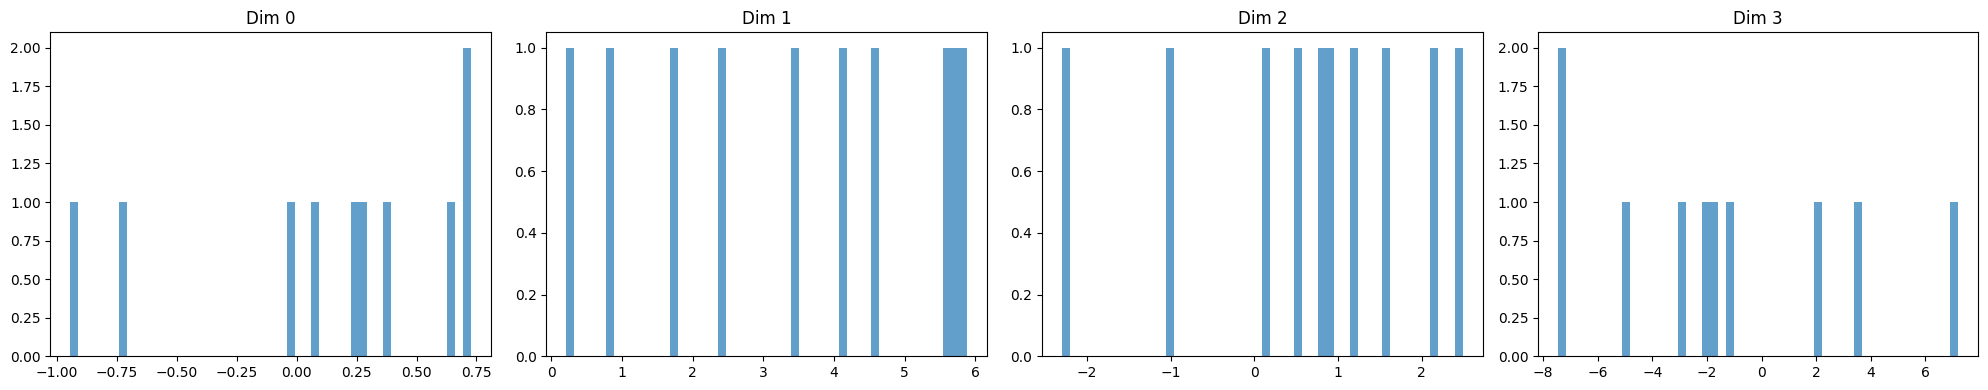

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, obs_uniform.shape[1], figsize=(20, 4))
for i in range(obs_uniform.shape[1]):
    axes[i].hist(obs_uniform[:, i], bins=50, color="C0", alpha=0.7)
    axes[i].set_title(f"Dim {i}")
plt.tight_layout()
plt.show()

In [27]:
results_state = evaluate_autonomous_rollouts(agent_state,
                                             env_state,
                                             obs_uniform,
                                             steps_to_run=50,
                                             is_rgb=False)

results_rgb = evaluate_autonomous_rollouts(agent_rgb,
                                           env_rgb,
                                           obs_uniform,
                                           steps_to_run=50,
                                           is_rgb=True)

100%|██████████| 10/10 [00:01<00:00,  5.30it/s]


In [28]:
def get_bootstrap_ci(results,
                     metric_key='r2_latent_per_time',
                     n_bootstrap=1000,
                     confidence=0.95,
                     label=None,
                     color=None):
    """
    Plot mean with bootstrap confidence interval.
    """
    data = np.array([r[metric_key] for r in results])
    n_rollouts, n_timesteps = data.shape

    # Bootstrap resampling
    bootstrap_means = np.zeros((n_bootstrap, n_timesteps))
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_rollouts, size=n_rollouts, replace=True)
        bootstrap_means[i] = np.mean(data[indices], axis=0)

    # Compute percentiles
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(bootstrap_means, alpha * 100, axis=0)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha) * 100, axis=0)
    mean = np.mean(data, axis=0)

    return mean, ci_lower, ci_upper

In [29]:
mean_state, ci_lower_state, ci_upper_state = get_bootstrap_ci(results_state)
mean_rgb, ci_lower_rgb, ci_upper_rgb = get_bootstrap_ci(results_rgb)

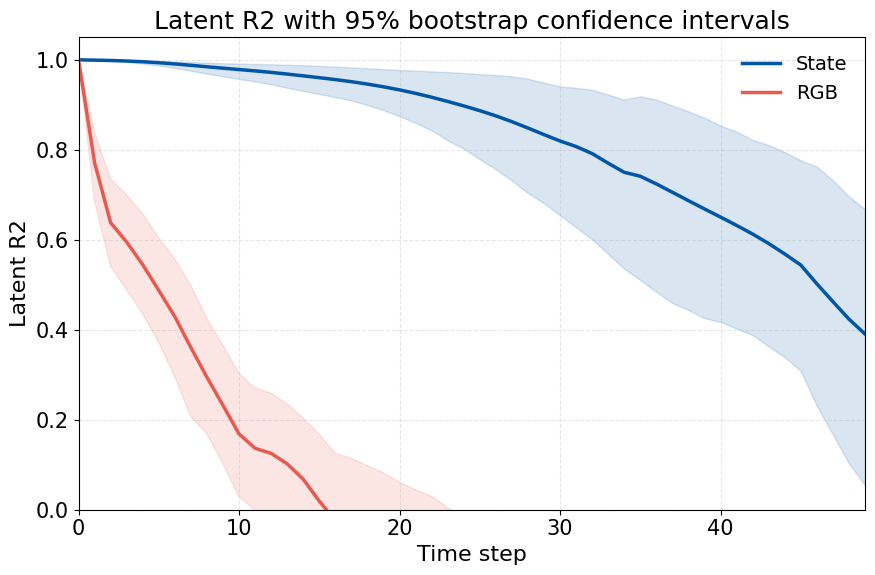

In [30]:
import matplotlib as mpl

plt.figure(figsize=(9, 6))
mpl.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14
})

timesteps = np.arange(len(mean_state))

plt.plot(timesteps, mean_state, color='#0056A6', lw=2.5, label="State")
plt.fill_between(timesteps,
                 ci_lower_state,
                 ci_upper_state,
                 color='#0056A6',
                 alpha=0.15)

plt.plot(timesteps, mean_rgb, color='#E85A4F', lw=2.5, label="RGB")
plt.fill_between(timesteps,
                 ci_lower_rgb,
                 ci_upper_rgb,
                 color='#E85A4F',
                 alpha=0.15)

plt.xlabel("Time step")
plt.ylabel("Latent R2")
plt.title("Latent R2 with 95% bootstrap confidence intervals")

plt.ylim(0, 1.05)
plt.xlim([timesteps[0], timesteps[-1]])
plt.grid(ls="--", alpha=0.3, zorder=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()